In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# For reproducibility
np.random.seed(42)

# Number of students
n = 200

# 1. Study hours per week (0 to 20 hours)
study_hours = np.random.randint(0, 15, n)

# 2. Attendance percentage (50% to 100%)
attendance = np.random.randint(50, 101, n)

# 3. Group discussion participation (Yes/No)
group_discussion = np.random.choice(['Yes', 'No'], size=n, p=[0.6, 0.4])

# 4. Previous test score (40 to 100)
previous_test_score = np.random.randint(40, 101, n)

# 5. Probability of passing depends on performance
# Higher study hours, attendance and previous score increase chance of passing

pass_probability = (
    0.3 * (study_hours / 20) +
    0.3 * (attendance / 100) +
    0.3 * (previous_test_score / 100) +
    0.1 * (group_discussion == 'Yes').astype(int)
)

# Convert probability into Pass/Fail
final_exam_pass = [
    'Pass' if np.random.rand() < prob else 'Fail'
    for prob in pass_probability
]

# Create DataFrame
df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'group_discussion': group_discussion,
    'previous_test_score': previous_test_score,
    'final_exam_pass': final_exam_pass
})

# Show first 10 rows
df.head(10)

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,6,86,Yes,89,Pass
1,3,72,No,66,Fail
2,12,88,Yes,97,Pass
3,14,94,No,41,Pass
4,10,64,No,44,Fail
5,7,92,No,68,Pass
6,12,78,Yes,76,Fail
7,4,85,Yes,77,Pass
8,6,62,No,58,Fail
9,9,81,Yes,47,Pass


In [50]:
#Empirical Probability
empirical=len(df[df['group_discussion']=='Yes'])/len(df)
print(empirical,"\n")

0.57 



In [44]:
#Theoretical Probability (Final Exam Pass/Fail)
theoretical=1/2
print(theoretical,"\n")

0.5 



In [56]:
#probability Table 
p=(df['final_exam_pass']=='Pass').sum()/len(df)
q=1-p
n=3
x={}

for k in range(4):
    x[k]=math.comb(n, k)*(p**k)*(q**(n-k))

print(x,"\n")

#mean of random variable
mean_of_r = n*p
print(mean_of_r,"\n")

#variance of random variable
var_of_r = n*p*q
print(var_of_r,"\n")


{0: np.float64(0.032767999999999985), 1: np.float64(0.20889599999999992), 2: np.float64(0.443904), 3: np.float64(0.31443200000000004)} 

2.04 

0.6527999999999999 



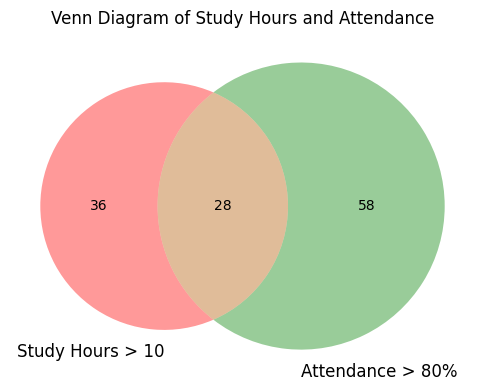

64
86


In [ ]:
#Venn Diagram
a=set(df[df['study_hours']>10].index)
b=set(df[df['attendance'] > 80].index)

plt.figure(figsize=(6,6))

venn2([a, b], set_labels=("Study Hours > 10", "Attendance > 80%"))

plt.title("Venn Diagram of Study Hours and Attendance")
plt.show()

print(len(a))
print(len(b))

In [74]:
#Contigency Table
contigency_table = pd.crosstab(df['group_discussion'],df['final_exam_pass'])
print(contigency_table)

#Joint Probability
j_p=contigency_table.loc['Yes','Pass']/len(df)
print(j_p,"\n")

#Marginal Probability
m_p=(df['final_exam_pass']=='Pass').mean()
print(m_p,"\n")

#Condtional probability
c_p=(contigency_table.loc['Yes','Pass']/contigency_table.loc["Yes"].sum())
print(c_p,"\n")


final_exam_pass   Fail  Pass
group_discussion            
No                  33    53
Yes                 31    83
0.415 

0.68 

0.7280701754385965 



In [75]:
#Bayes Theorem

# Given probabilities
P_high_given_pass = 0.70
P_high_given_fail = 0.40
P_high = 0.60

# Step 1: Solve for P(pass)
# 0.60 = 0.70x + 0.40(1 - x)

# Simplified:
# 0.60 = 0.30x + 0.40
# 0.20 = 0.30x

P_pass = 0.20 / 0.30

print("P(Pass) =", round(P_pass, 4))

# Step 2: Apply Bayes formula
P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass | High Attendance) =", round(P_pass_given_high, 4))


P(Pass) = 0.6667
P(Pass | High Attendance) = 0.7778
